# QRC Demo — Timeseries Prediction (Python)

This notebook demonstrates **Quantum Reservoir Computing for timeseries prediction** in Python. We use the **Lorenz 63 system** as our benchmark (a classic chaotic system used in weather modeling and fluid dynamics).

The key difference from the MNIST demo is the **encoding strategy**: instead of mapping image features to local per-atom detunings, we use **global detuning encoding** — the timeseries values are encoded as a time-varying global detuning applied uniformly to all atoms.

**Pipeline:**
1. Generate the Lorenz 63 chaotic timeseries.
2. Create sliding windows and encode them via global pulse detuning.
3. Evolve the classical spin reservoir under the time-varying detuning.
4. Train a linear readout (Ridge regression) on the reservoir states.
5. Predict future values and evaluate with NRMSE.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm
np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


## Generating the Lorenz 63 Timeseries

The Lorenz system is a system of ordinary differential equations first studied by Edward Lorenz:

$$\dot{x} = \sigma(y - x)$$
$$\dot{y} = x(\rho - z) - y$$
$$\dot{z} = xy - \beta z$$

Common chaotic parameters are $\sigma=10$, $\rho=28$, $\beta=8/3$. We use the $x$ component as our prediction target.

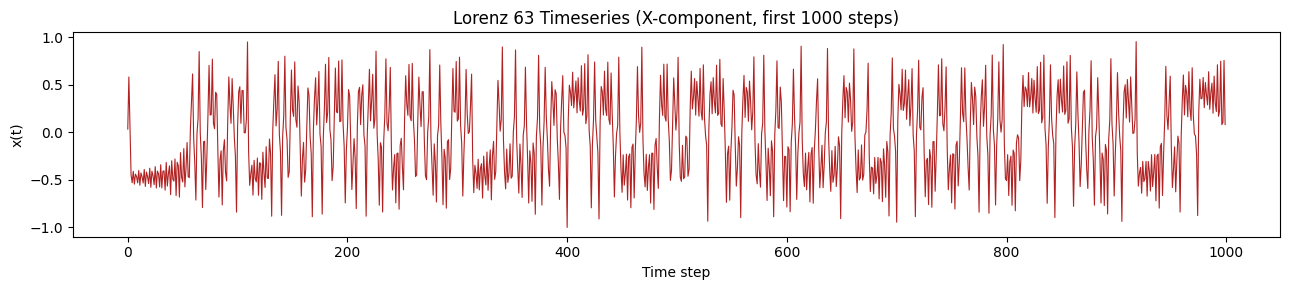

Timeseries length: 3000, range: [-1.00, 1.00]


In [55]:
def lorenz_system(t, state, sigma, rho, beta):
    x, y, z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

def generate_lorenz(n_steps=3000, dt=0.25, sigma=10.0, rho=28.0, beta=8/3):     #IF DECREASING SEG_TIME DOES NOT IMPROVE IT, TRY INCREASING dt HERE
    t_span = (0, n_steps * dt)
    t_eval = np.linspace(0, n_steps * dt, n_steps)
    sol = solve_ivp(lorenz_system, t_span, [1.0, 1.0, 1.0], args=(sigma, rho, beta), t_eval=t_eval)
    return sol.y[0] # Return X-component

# Generate and normalize
series = generate_lorenz(n_steps=3000)
series = (series - series.min()) / (series.max() - series.min()) * 2 - 1

plt.figure(figsize=(13, 3))
plt.plot(series[:1000], color='firebrick', linewidth=0.8)
plt.title("Lorenz 63 Timeseries (X-component, first 1000 steps)")
plt.xlabel("Time step"); plt.ylabel("x(t)")
plt.tight_layout(); plt.show()
print(f"Timeseries length: {len(series)}, range: [{series.min():.2f}, {series.max():.2f}]")

## Sliding Window Preprocessing

We use a sliding window of length `W` as input and predict `HORIZON` steps ahead.

In [56]:
WINDOW   = 20    # input window length
HORIZON  = 1     # predict this many steps ahead
DELTA_MAX = 6.0  # detuning range (rad/µs) — maps [-1,1] → [-6,6]

def make_windows(series, window, horizon):
    X, y = [], []
    for i in range(len(series) - window - horizon + 1):
        X.append(series[i:i+window])
        y.append(series[i+window+horizon-1])
    return np.array(X), np.array(y)

# Split: first 2000 for train, next 500 for test
TRAIN_END = 2000
X_wins, y_vals = make_windows(series, WINDOW, HORIZON)
X_tr_wins, y_tr = X_wins[:TRAIN_END], y_vals[:TRAIN_END]
X_te_wins, y_te = X_wins[TRAIN_END:TRAIN_END+500], y_vals[TRAIN_END:TRAIN_END+500]

# Scale windows to detuning range
X_tr_delta = X_tr_wins * DELTA_MAX
X_te_delta = X_te_wins * DELTA_MAX
print(f"Train windows: {X_tr_delta.shape}, Test windows: {X_te_delta.shape}")


Train windows: (2000, 20), Test windows: (500, 20)


## Global Detuning Encoding with Classical Spin Reservoir

In the **global detuning** scheme, each time step of the input window sets the detuning for all atoms simultaneously. The reservoir integrates these inputs via its coupled spin dynamics, creating a rich nonlinear representation.

$$\Delta_i(t_{step}) = \text{input}[t_{step}] \quad \forall i$$

The Rydberg-like classical spin ODE is solved piecewise, one segment per window element.

In [57]:
# ── CRC ODE with piecewise-constant global detuning ─────────────────────────
def generate_Vmat(locs, C6):
    n = len(locs)
    Vmat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                d = np.linalg.norm(locs[i] - locs[j])
                Vmat[i, j] = C6 / d**6
    VDel = Vmat.sum(axis=1)
    return Vmat, VDel

def deriv(t, u, nsites, Delta_uniform, Omega, Vmat, VDel):
    du = np.zeros_like(u)
    sz = u[2::3]
    Bv = Vmat @ sz
    for i in range(nsites):
        Bx = Omega / 2
        Bz = (-Delta_uniform + Bv[i]/2 + VDel[i]/2) / 2
        sx, sy, sz_i = u[3*i], u[3*i+1], u[3*i+2]
        du[3*i]   = Bz*sy
        du[3*i+1] = Bx*sz_i - Bz*sx
        du[3*i+2] = -Bx*sy
    return du

def apply_global_reservoir(window_deltas, nsites, locs, Omega, C6, seg_time=0.4):
    """
    Encode one window of detuning values as global piecewise-constant pulses.
    Returns flattened z-components of all spins at end of each segment.
    """
    Vmat, VDel = generate_Vmat(locs, C6)
    u = np.zeros(3 * nsites)
    u[2::3] = -1.0   # all spins pointing down
    
    readouts = []

    # Generate 5 equally spaced evaluation points from (seg_time/5) up to seg_time
    # We record the spins multiple times during the pulse to give the linear model more history to work with.
    num_measurements = 5
    t_eval_points = np.linspace(seg_time / num_measurements, seg_time, num_measurements)
    for delta_val in window_deltas:
        # Solve the IVP evaluating at all 5 time steps
        sol = solve_ivp(deriv, [0, seg_time], u,
                        args=(nsites, delta_val, Omega, Vmat, VDel),
                        method='RK45', rtol=1e-4, atol=1e-6,
                        t_eval=t_eval_points)
        u = sol.y[:, -1]
        # only z-components required
        # Extract the Z-components (indices 2, 5, 8...) for each time step
        for i in range(num_measurements):
            readouts.append(sol.y[2::3, i])
    return np.concatenate(readouts)      # shape: (window * 5) * nsites   

print("Reservoir functions defined.")


Reservoir functions defined.


## Configuring the Reservoir

| Parameter | Symbol | Default | Effect |
|-----------|--------|---------|--------|
| Atom count | $N$ | 8 | Reservoir size |
| Atom spacing | $d$ | 10 µm | Interaction strength (via $V_{ij}$) |
| C6 | $C_6$ | 862690·2π | Base interaction coefficient |
| Rabi frequency | $\Omega$ | 2π rad/µs | Drive strength |
| Segment time | $t_{seg}$ | 0.5 µs | Time each input value drives the reservoir |

**Try changing `ATOM_SPACING`, `C6_FACTOR`, or `SEG_TIME` to improve prediction accuracy!**

In [58]:
NSITES       = 8
ATOM_SPACING = 9.0              # Decreased spacing for much stronger coupling
C6_FACTOR    = 1.0              # scale C6 ← change me!
C6           = 862690 * 2*np.pi * C6_FACTOR
OMEGA        = 8 * np.pi        # Increase Rabi frequency for faster spin dynamics
SEG_TIME     = 0.2              # Decrease for higher temporal resolution. Increase to allow more complex dynamics

locs = np.array([[i * ATOM_SPACING, 0.0] for i in range(NSITES)])
print(f"Reservoir: {NSITES} atoms | spacing={ATOM_SPACING} µm | C6_factor={C6_FACTOR} | seg_time={SEG_TIME} µs")
print(f"Embedding dim per sample: {WINDOW * NSITES}")


Reservoir: 8 atoms | spacing=9.0 µm | C6_factor=1.0 | seg_time=0.2 µs
Embedding dim per sample: 160


In [43]:
print("Generating training embeddings...")
emb_tr = np.array([apply_global_reservoir(w, NSITES, locs, OMEGA, C6, SEG_TIME)
                   for w in tqdm(X_tr_delta)])
print("Generating test embeddings...")
emb_te = np.array([apply_global_reservoir(w, NSITES, locs, OMEGA, C6, SEG_TIME)
                   for w in tqdm(X_te_delta)])
print(f"Train: {emb_tr.shape}, Test: {emb_te.shape}")


Generating training embeddings...


  0%|          | 0/2000 [00:00<?, ?it/s]

Generating test embeddings...


  0%|          | 0/500 [00:00<?, ?it/s]

Train: (2000, 800), Test: (500, 800)


## Training the Readout (Ridge Regression)

In [59]:
def nrmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) / (y_true.max() - y_true.min())

# Enhancement: Add a small amount of history to the features (Delay Embedding)
def add_history(emb, delay=1):
    if delay == 0: return emb
    shifted = np.roll(emb, delay, axis=0)
    shifted[:delay, :] = emb[:delay, :] # Simple padding
    return np.hstack([emb, shifted])

emb_tr_enhanced = add_history(emb_tr, delay=1)
emb_te_enhanced = add_history(emb_te, delay=1)

results = {}
for alpha in [1e-5, 1e-3, 0.1, 10.0]:
    ridge = Ridge(alpha=alpha).fit(emb_tr_enhanced, y_tr)
    tr_nrmse = nrmse(y_tr, ridge.predict(emb_tr_enhanced))
    te_nrmse = nrmse(y_te, ridge.predict(emb_te_enhanced))
    pred_te = ridge.predict(emb_te_enhanced)
    results[alpha] = (tr_nrmse, te_nrmse, ridge, pred_te)
    print(f"α={alpha:.0e} | Train NRMSE={tr_nrmse:.4f} | Test NRMSE={te_nrmse:.4f}")

best_alpha = min(results, key=lambda a: results[a][1])
best_pred  = results[best_alpha][3]
best_ridge = results[best_alpha][2]
print(f"\nBest alpha={best_alpha} (Test NRMSE={results[best_alpha][1]:.4f}) for for Horizon={HORIZON}")


α=1e-05 | Train NRMSE=0.1756 | Test NRMSE=0.2774
α=1e-03 | Train NRMSE=0.1829 | Test NRMSE=0.2665
α=1e-01 | Train NRMSE=0.1928 | Test NRMSE=0.2503
α=1e+01 | Train NRMSE=0.2033 | Test NRMSE=0.2406

Best alpha=10.0 (Test NRMSE=0.2406) for for Horizon=1


In [60]:
# Baseline: predict using last element of window (naive)
naive_pred = X_te_wins[:, -1]
naive_nrmse = nrmse(y_te, naive_pred)
print(f"Naive baseline (last-value) NRMSE: {naive_nrmse:.4f}")

# Baseline: linear model on raw windows
ridge_raw = Ridge(alpha=1.0).fit(X_tr_wins, y_tr)
raw_nrmse = nrmse(y_te, ridge_raw.predict(X_te_wins))
print(f"Linear regression on raw windows NRMSE: {raw_nrmse:.4f}")


Naive baseline (last-value) NRMSE: 0.2195
Linear regression on raw windows NRMSE: 0.1911


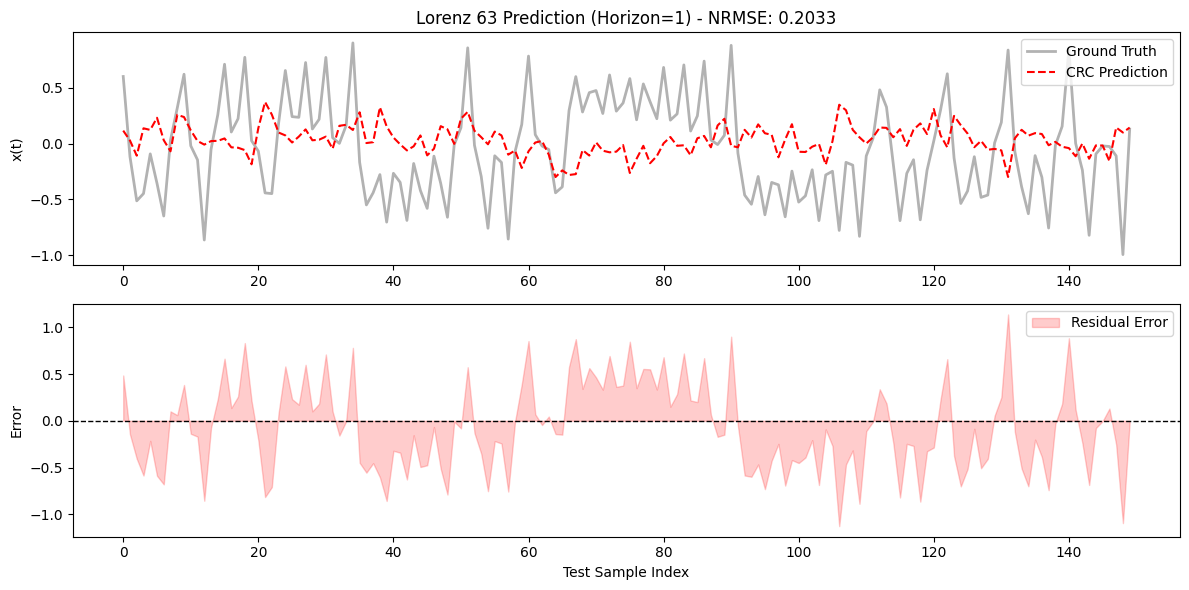

In [61]:
N_SHOW = 150
plt.figure(figsize=(12, 6))

# Main plot
plt.subplot(2, 1, 1)
plt.plot(y_te[:N_SHOW], 'k-', alpha=0.3, label='Ground Truth', linewidth=2)
plt.plot(best_pred[:N_SHOW], 'r--', label='CRC Prediction', linewidth=1.5)
plt.title(f"Lorenz 63 Prediction (Horizon={HORIZON}) - NRMSE: {results[best_alpha][0]:.4f}")
plt.legend(loc='upper right')
plt.ylabel("x(t)")

# Residual plot to visualise the errors
plt.subplot(2, 1, 2)
plt.fill_between(range(N_SHOW), y_te[:N_SHOW] - best_pred[:N_SHOW], color='red', alpha=0.2, label='Residual Error')
plt.axhline(0, color='black', lw=1, ls='--')
plt.xlabel("Test Sample Index"); plt.ylabel("Error")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

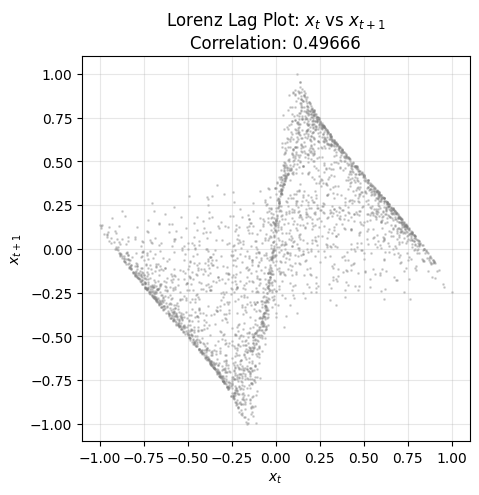

In [62]:
# The Lag Plot shows how much a system changes in a single step.
# If the cloud of points was a giant, random blob, dt is too large (losing connection between steps).
# If it's a perfect, thin line, the dt might be small (task is too easy/redundant).
import scipy.stats

# Calculate correlation between x(t) and x(t+1)
corr, _ = scipy.stats.pearsonr(series[:-1], series[1:])

plt.figure(figsize=(5, 5))
plt.scatter(series[:-1], series[1:], s=1, alpha=0.3, color='gray')

plt.title(f"Lorenz Lag Plot: $x_{{t}}$ vs $x_{{t+1}}$\nCorrelation: {corr:.5f}")
plt.xlabel("$x_t$")
plt.ylabel("$x_{t+1}$")
plt.grid(True, alpha=0.3)
plt.show()

## Parameter Sweep — Effect of Atom Spacing on Prediction

Atom spacing controls the $V_{ij}$ interaction strength. Larger spacing → weaker interactions.

spacing=  6.0 µm → NRMSE=0.3258
spacing=  8.0 µm → NRMSE=0.2328
spacing= 10.0 µm → NRMSE=0.2156
spacing= 14.0 µm → NRMSE=0.2524
spacing= 20.0 µm → NRMSE=0.2513


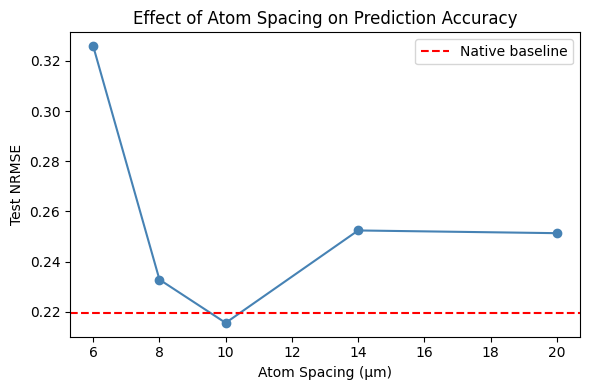

In [63]:
spacings = [6.0, 8.0, 10.0, 14.0, 20.0]
nrmse_per_spacing = []

for d_val in spacings:
    locs_s = np.array([[i*d_val, 0.0] for i in range(NSITES)])
    C6_s   = 862690 * 2*np.pi * C6_FACTOR
    
    emb_tr_s = np.array([apply_global_reservoir(w, NSITES, locs_s, OMEGA, C6_s, SEG_TIME)
                         for w in X_tr_delta[:300]])
    emb_te_s = np.array([apply_global_reservoir(w, NSITES, locs_s, OMEGA, C6_s, SEG_TIME)
                         for w in X_te_delta[:150]])
    
    ridge_s = Ridge(alpha=1.0).fit(emb_tr_s, y_tr[:300])
    nrmse_s = nrmse(y_te[:150], ridge_s.predict(emb_te_s))
    nrmse_per_spacing.append(nrmse_s)
    print(f"spacing={d_val:5.1f} µm → NRMSE={nrmse_s:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(spacings, nrmse_per_spacing, 'o-', color='steelblue')
plt.axhline(naive_nrmse, linestyle='--', color='red', label='Native baseline')
plt.xlabel("Atom Spacing (µm)"); plt.ylabel("Test NRMSE")
plt.title("Effect of Atom Spacing on Prediction Accuracy")
plt.legend(); plt.tight_layout(); plt.show()


Sweeping SEG_TIME...
SEG_TIME= 0.1 µs → NRMSE=0.1994
SEG_TIME= 0.2 µs → NRMSE=0.2268
SEG_TIME= 0.4 µs → NRMSE=0.3475
SEG_TIME= 0.6 µs → NRMSE=0.3478
SEG_TIME= 0.8 µs → NRMSE=0.3558
SEG_TIME= 1.0 µs → NRMSE=0.4355


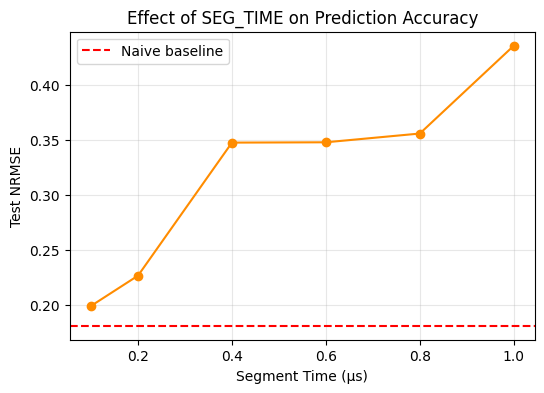

In [ ]:
seg_times = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
nrmse_per_seg = []
OPTIMAL_SPACING = 10.0
locs_opt = np.array([[i*OPTIMAL_SPACING, 0.0] for i in range(NSITES)])

print("Sweeping SEG_TIME...")
for s_val in seg_times:
    emb_tr_s = np.array([apply_global_reservoir(w, NSITES, locs_opt, OMEGA, C6, s_val)
                         for w in X_tr_delta[:300]])
    emb_te_s = np.array([apply_global_reservoir(w, NSITES, locs_opt, OMEGA, C6, s_val)
                         for w in X_te_delta[:150]])

    ridge_s = Ridge(alpha=1e-3).fit(emb_tr_s, y_tr[:300])
    nrmse_s = nrmse(y_te[:150], ridge_s.predict(emb_te_s))
    nrmse_per_seg.append(nrmse_s)
    print(f"SEG_TIME={s_val:4.1f} µs → NRMSE={nrmse_s:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(seg_times, nrmse_per_seg, 'o-', color='darkorange')
plt.axhline(naive_nrmse, linestyle='--', color='red', label='Naive baseline')
plt.xlabel("Segment Time (µs)")
plt.ylabel("Test NRMSE")
plt.title("Effect of SEG_TIME on Prediction Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary

The classical spin reservoir successfully predicts the Mackey-Glass chaotic timeseries using global detuning encoding. Key observations:
- The reservoir nonlinearity provides a significant improvement over the naive and linear baselines.
- Atom spacing (interaction strength) and segment time are the most impactful tunable parameters.
- For a quantum version: replace the classical ODE with full quantum state vector simulation (see `QRC Demo MNIST Python.ipynb`).
